In [12]:
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

In [13]:
from scipy.stats import norm, vonmises, special_ortho_group, uniform, multivariate_normal, chi2, t as student_t
from scipy.special import erf
from math import sqrt
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import torch
import warnings

%reload_ext autoreload
%autoreload 2

from precomputation.initialization import *
from misc.common_functions import load_config
from master.data.rotated_shapes import RotatedData
#from master.data.sigmoid_data_old import SigmoidData
from master.data.smoothstep_data import SmoothstepData
from inflation.jupyter_helper import *
from misc.common_functions import *

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
#matplotlib.use("pdf")

# State Densities

In [54]:
TITLE_SIZE = 15
LEGEND_SIZE = 14
AXIS_TITLE_SIZE = 18
    
mises_params_05 = {'kappa': 0.5}
mises_params_4 = {'kappa': 6}
norm_params = {'loc': 0, 'scale': 1}
uniform_params = {'loc': -0.5, 'scale': 1}
student_params = {'df': 4}
smoothstep_params = dict(dimension=36, start=-5, end=5, offset=1, Range=10, growth=0.5, data_mode='sampled')

mises_clr = 'tab:purple'
gauss_clr = 'tab:red'
step_clr = 'tab:cyan'
uni_clr = 'tab:olive'
noise_clr = 'tab:gray'
student_clr = 'tab:pink'

In [112]:
def dist_plotter(data, label, color, ax, bw_adjust=None):
    if bw_adjust is None:
        bw_adjust = 0.4
    sns.distplot(data, label=label, color=color, hist=False,
                 ax=ax, kde_kws={'bw_adjust': bw_adjust}, kde=True, bins=100)

def plot_density_state_for_dist(dist, kwargs, label, color, log, ax, hist=False):
    samples = dist.rvs(**kwargs, size=STATE_DENSITY_SAMPLE_COUNT)
    if log:
        pds = dist.logpdf(samples, **kwargs)
    else:
        pds = dist.pdf(samples, **kwargs)
    sns.distplot(pds, label=label, color=color, hist=hist, ax=ax, kde_kws={'bw_adjust': 0.5}, kde=True, bins=1000, norm_hist=True)
    return pds

#----------------------------------------
    
def plot_pdfs(ax):
    ax.set_xlim([-6, 6])
    z = np.linspace(-6, 6, STATE_DENSITY_SAMPLE_COUNT)
    # mises pdf
    pds = vonmises.pdf(z, **mises_params_05)
    pds[np.logical_or(z < -np.pi, z > np.pi)] = 0
    ax.plot(z, pds, '-', color=mises_clr, label='von Mises κ=0.5')

    #pds = norm.pdf(z, **norm_params)
    #ax.plot(z, pds, '-', color=gauss_clr, label='N(0, 1)')
    
    #pds = student_t.pdf(z, **student_params)
    #ax.plot(z, pds, '-', color=student_clr, label='Student t')

    step_data = SmoothstepData(**smoothstep_params, size=10)
    pds = step_data.pdf_on_manifold(z)
    
    ax.plot(z, pds, '-', color=step_clr, label='Smooth Step')
    
    pds = uniform.pdf(z, **uniform_params)
    #pds[np.logical_or(z < -np.pi, z > np.pi)] = 0
    ax.plot(z, pds, '-', color=uni_clr, label='Uniform[-.5, .5]')
    
    ax.set_xlabel('x', size=AXIS_TITLE_SIZE)
    ax.set_ylabel('p(x)', size=AXIS_TITLE_SIZE)
    ax.set_title('PDF', size=TITLE_SIZE)
    
def plot_density_states(log, ax):    
    
    #plot_density_state_for_dist(norm, norm_params, label='Gauss', color=gauss_clr, log=log, ax=ax, hist=True)
    #plot_density_state_for_dist(student_t, student_params, label='Studen t', color=student_clr, log=log, ax=ax, hist=True)

    # True Gauss
    """x = np.linspace(-6, -0.75, STATE_DENSITY_SAMPLE_COUNT)
    density = 2 * chi2.pdf(df=1, x=-(2 * x + np.log(2 * np.pi)))
    if log:
        plt.plot(x, density, '-', color='r', label='N(0, 1)')
    else:
        raise Exception('Dunno')
    """    
    #plt.plot(x, density, '-', color='k', label='"True" Gauss')
        
    ### SmoothStep
    step_data = SmoothstepData(size=STATE_DENSITY_SAMPLE_COUNT, **smoothstep_params)
    pds = step_data.densities['inflated_manifold_log_pd']
    
    if not log:
        pds = np.exp(pds)
    dist_plotter(pds, 'Smooth Step', step_clr, ax)
    
    ax.axvline(x=0, color=uni_clr, label='Uniform')
    
    plot_density_state_for_dist(vonmises, mises_params_05, label='von Mises', color=mises_clr, log=log, ax=ax, hist=False)
    
    x_label = 'log( p(x) ) =: y' if log else 'p(x)'
    ax.set_xlabel(x_label, size=AXIS_TITLE_SIZE)
    #ax.set_ylabel(f'p( {x_label} )')
    ax.set_ylabel(f'p(y)', size=AXIS_TITLE_SIZE)
    ax.set_title('Density of States', size=TITLE_SIZE, y=0.99)
    
def axs_formatter(axs, size=15):
    for ax in axs:
        ax.legend(fontsize=LEGEND_SIZE)
        ax.xaxis.label.set_size(size)
        ax.yaxis.label.set_size(size)
        

Note that SmSt has Dirac Points at ~0.2 and ~0.04. However this is not nicely depictable.Thus the smoothing of this distlot visualizes this quite well.
There is more mass in the higher part of smooth step than in the lower! (Around 3.5 times more mass)


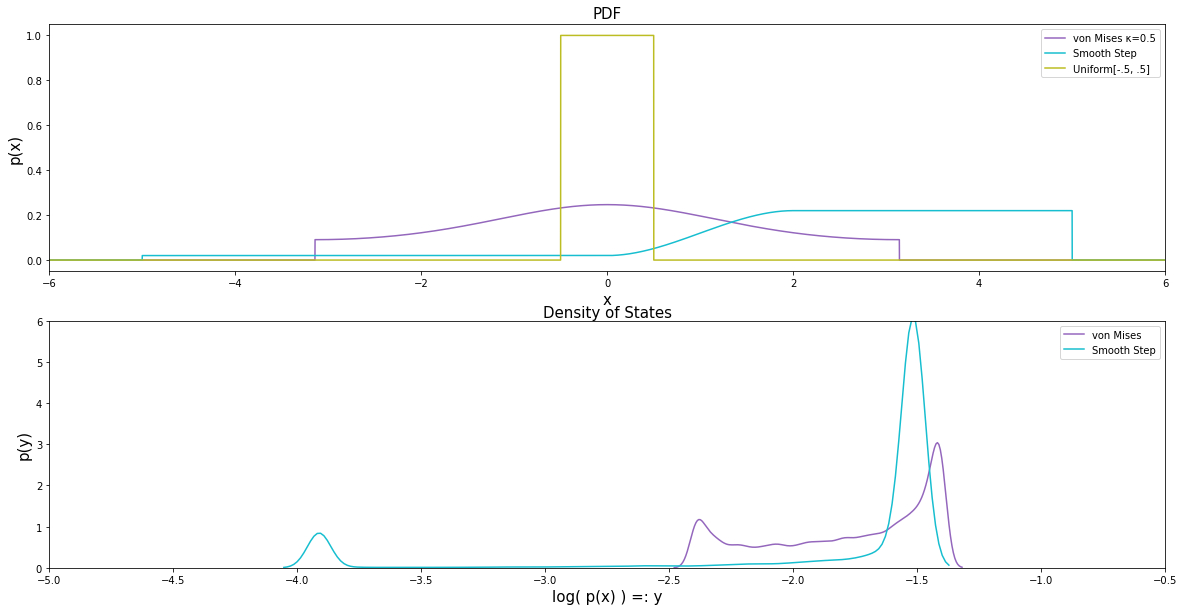

In [16]:
STATE_DENSITY_SAMPLE_COUNT = 10000
#STATE_DENSITY_SAMPLE_COUNT = 2000

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), squeeze=True)

#smoothstep_params = dict(dimension=36, start=-1, end=1, offset=1, Range=2, growth=3, data_mode='sampled')
#step_data = SmoothstepData(size=STATE_DENSITY_SAMPLE_COUNT, **smoothstep_params)
#dist_plotter(step_data.data[NONE_EMBEDDED_DATA][0], 'Smooth Step', step_clr, axs[0])

plot_pdfs(ax=axs[0])
plot_density_states(log=True, ax=axs[1])
axs[1].set_xlim([-5, -0.5])
axs[1].set_ylim(top=6)
#plot_density_states(log=True, ax=axs[2])

axs_formatter(axs)
#plot_density_states(log=True, ax=axs[1])
fig.savefig(f'densities/mani_pdf_dos.png')
print('Note that SmSt has Dirac Points at ~0.2 and ~0.04. However this is not nicely depictable.' 
      + 'Thus the smoothing of this distlot visualizes this quite well.')
print('There is more mass in the higher part of smooth step than in the lower! (Around 3.5 times more mass)')

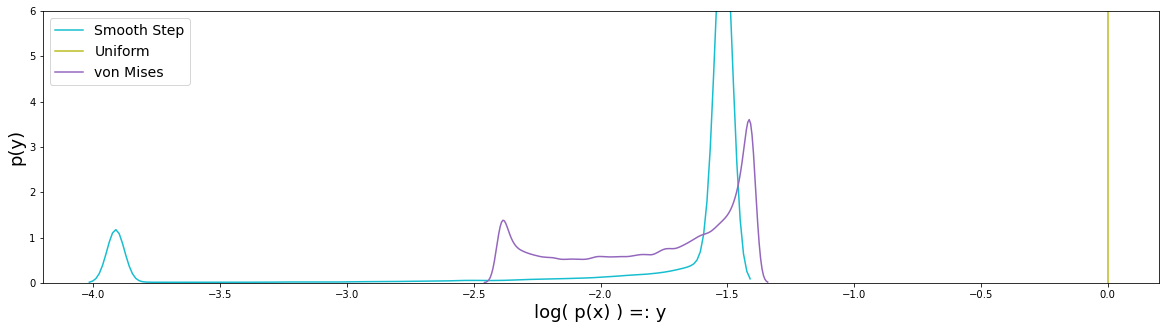

In [113]:
STATE_DENSITY_SAMPLE_COUNT = 50000

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=True)

plot_density_states(log=True, ax=ax)
ax.set_xlim([-4.2, 0.2])
ax.set_ylim(top=6)
ax.set_title('')
ax.legend(fontsize=LEGEND_SIZE)

plt.savefig('E:/pure_mani_dos.pdf', format='pdf', bbox_inches='tight')

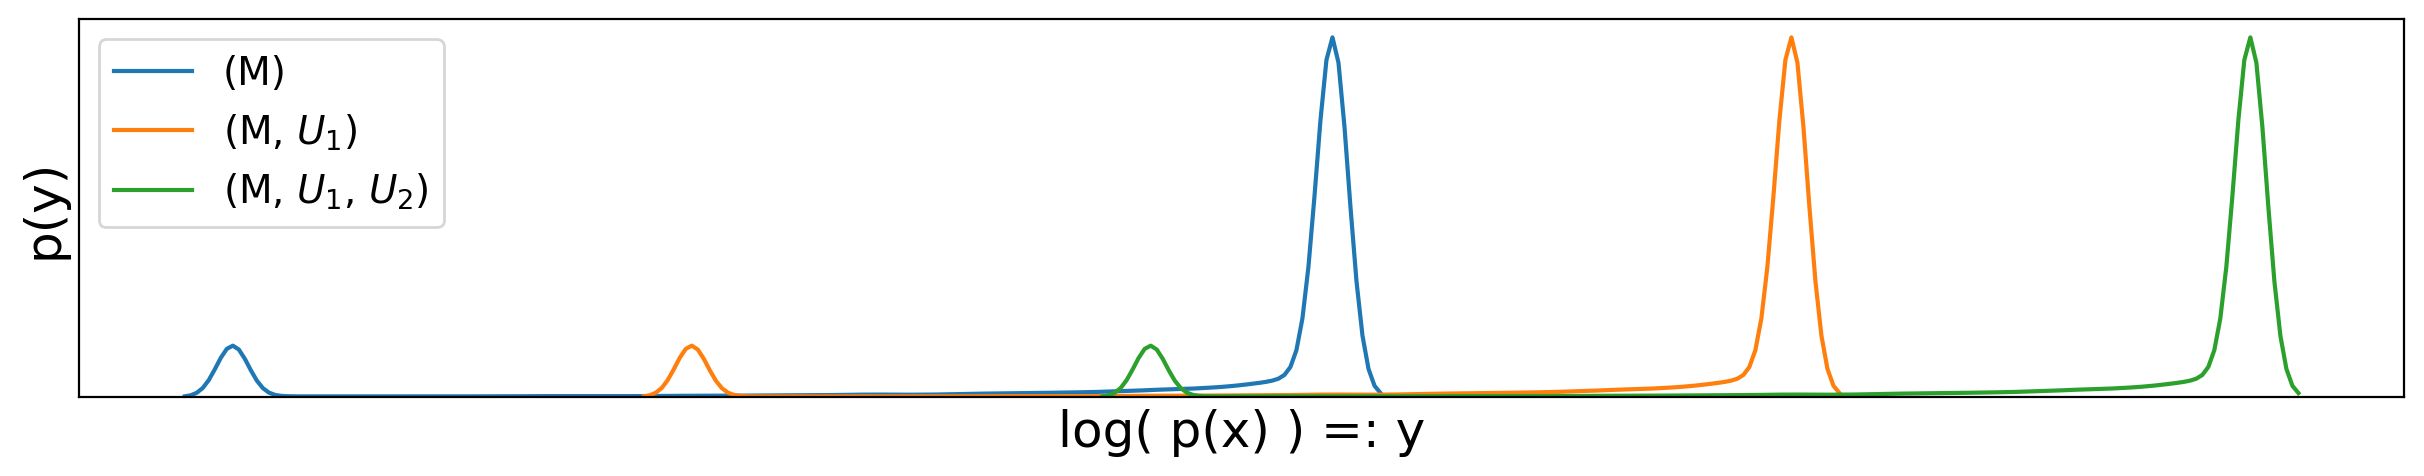

In [57]:
#fig, axs = plt.subplots(nrows=len(used_variances), ncols=1, figsize=(15, int(len(used_variances)*2.5)), squeeze=False, dpi=200)

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 2.5), squeeze=True, dpi=200)

STATE_DENSITY_SAMPLE_COUNT=50000
step_data = SmoothstepData(size=STATE_DENSITY_SAMPLE_COUNT, **smoothstep_params)
pds = step_data.densities['inflated_manifold_log_pd']
dist_plotter(pds, '(M)', color=None, ax=axs)

pds = step_data.densities['inflated_manifold_log_pd'] + 1
dist_plotter(pds, '(M, $U_1$)', color=None, ax=axs)

pds = step_data.densities['inflated_manifold_log_pd'] + 2
dist_plotter(pds, '(M, $U_1$, $U_2$)', color=None, ax=axs)


x_label = 'log( p(x) ) =: y'
axs.set_xlabel(x_label, size=AXIS_TITLE_SIZE)
#ax.set_ylabel(f'p( {x_label} )')
axs.set_ylabel(f'p(y)', size=AXIS_TITLE_SIZE)
axs.set_yticks([])
axs.set_xticks([])

#handles, labels = axs.get_legend_handles_labels()
#fig.legend(handles, labels, loc=(0.7, 0.85))
#fig.legend(handles, labels, loc='center right')
axs.legend(fontsize=LEGEND_SIZE)
    
plt.savefig('E:/dirac_dos_change.pdf', format='pdf', bbox_inches='tight')

------
# Adding Noise

In [7]:
LEFT_QUANTILE_CUT_OFF = 0.02
STATE_DENSITY_SAMPLE_COUNT = 10000

def add_density_of_normal_dimensions(pds, additional_dimensions, scale, log):
    """Will add the pdfs of additional dimensions which have only normal distributions in them."""
    var_buffer = pds
    if additional_dimensions > 0 and scale is not None:
        additional_dim_samples = norm.rvs(scale=scale, size=(len(pds), additional_dimensions))
        single_add_log_pds = norm.logpdf(additional_dim_samples, scale=scale)
        
        var_buffer = np.concatenate((var_buffer, single_add_log_pds.flatten()))
        
        additional_log_pds = single_add_log_pds.sum(1)
        if log:
            pds += additional_log_pds
        else:
            pds *= np.exp(additional_log_pds)
            
    return pds, (var_buffer.mean(), var_buffer.var())

def density_state_add_normal_noise(log, sampling, pdf, variance, additional_dimensions, label, color, ax, normalization=None, **dist_args):
    """additional_dimensions: will "add" normal noise in other dimensions. If 0 we don't use other dims"""
    sample_N = STATE_DENSITY_SAMPLE_COUNT
    total_dims = additional_dimensions + 1
    # sample X + N
    samples = sampling(size=sample_N, **dist_args)
    samples = np.double(samples)
    #samples = sampling(size=sample_N, **dist_args)
    if True: # Davids special case, no noise to manifold
        print('special case activated;  no noise to manifold')
        pd_of_samples = pdf(samples, **dist_args)
        scale = np.sqrt(variance)
    else:
        if variance is not None:
            scale = np.sqrt(variance)
            samples += norm.rvs(scale=scale, size=sample_N)
            # as there is a closed form solution for the uniform pdf
            if pdf == uniform.pdf:
                pd_of_samples = pdf_N_plus_Uni(samples, variance)
            else:
                # sample for convolution
                convolve_size = 2000
                normal_samples = norm.rvs(scale=scale, size=convolve_size)
                normal_samples = normal_samples.repeat(sample_N).reshape(convolve_size, sample_N)
                # convolution
                pd_of_samples = np.mean(pdf(samples - normal_samples, **dist_args), axis=0)
        else:
            pd_of_samples = pdf(samples, **dist_args)
            scale = None
        
    #pd_of_samples = pdf(samples, **dist_args)
    
    # happens rarely but is a pain
    if (pd_of_samples == 0).mean() > 0.005: raise Exception('Too many strange samples!')
    pd_of_samples = pd_of_samples[pd_of_samples != 0]
    
    if log:
        pd_of_samples = np.log(pd_of_samples)
    
    pd_of_samples, (mean, var) = add_density_of_normal_dimensions(pd_of_samples, additional_dimensions, scale=scale, log=log)
    
    # - 1e-5 as it could be (for smooth step) that 10% off all data are exactly on this quantile
    if normalization == 'central_limit':
        log_pds = pd_of_samples
    else:
        log_pds = pd_of_samples[pd_of_samples > quantile_finder(pd_of_samples, LEFT_QUANTILE_CUT_OFF)[0] - 1e-5]
    
    #log_pdf = norm.logpdf(samples).sum(0)
    
    #z_n = (log_pdf - dim*log_pdf_single.mean()) / (np.sqrt(dim) * np.sqrt(log_pdf_single.var())) 

    if normalization == 'central_limit':
        n_times_mu = log_pds / total_dims
        #log_pds = (log_pds - mean * total_dims) / (np.sqrt(var) * np.sqrt(total_dims))
        log_pds = (log_pds - log_pds.mean()) / np.sqrt(log_pds.var())
    elif normalization == 'central_limit_norm':
        div_by_dim = log_pds / total_dims
        n_times_mu = div_by_dim - div_by_dim.mean()
        log_pds = n_times_mu * np.sqrt(total_dims)
        #log_pds = n_times_mu# log_pds - log_pds.mean()
    elif normalization == 'div_dim':
        # norm for all dimensions
        log_pds /= total_dims
    elif normalization == None:
        ...
    else:
        log_pds = None
    print(f'{label} Var: {np.log10(variance)} Dim: {total_dims} Mean: {log_pds.mean():.3f}')
    # lines sometimes have no variance
    if log_pds.var() < np.finfo(np.float32).eps:
        ax.axvline(log_pds[0], color=color, label=label)
    else:
        sns.distplot(log_pds, label=label, color=color, hist=False, norm_hist=True, ax=ax, kde_kws={'bw_adjust': 1}, kde=True)


In [96]:
def plot_state_densities_in_one_plot(dist, log_variance, ax, log, additional_dimensions, by_variance_or_dimension, 
                                     color_idx, normalization='div_dim'):
    if log_variance is None:
        noise_label = f'{gauss_symbol()}(σ²=0)'
        variance = None
    else:
        variance = 10.**log_variance
        noise_label = f'{gauss_symbol()}(σ²={var_to_label(variance)})'
    if by_variance_or_dimension == 'dimension':
        noise_label = f'D = {additional_dimensions+1}'
        
    kwargs = dict(variance=variance, ax=ax, log=log, additional_dimensions=additional_dimensions, 
                  color=sns.color_palette("tab10")[color_idx], label=noise_label, normalization=normalization)
    
    if dist == 'smooth_step':
        step_data = SmoothstepData(**smoothstep_params, size=10)
        density_state_add_normal_noise(sampling=step_data.sample_on_manifold, pdf=step_data.pdf_on_manifold, **kwargs)
    elif dist == 'mises':
        density_state_add_normal_noise(sampling=vonmises.rvs, pdf=vonmises.pdf, **mises_params_05, **kwargs)
    elif dist == 'line':
        density_state_add_normal_noise(sampling=uniform.rvs, pdf=uniform.pdf, **uniform_params, **kwargs)
    elif dist == 'normal':
        density_state_add_normal_noise(sampling=norm.rvs, pdf=norm.pdf, **norm_params, **kwargs)



def plot_state_density_variance_transition(distribution, plot_by_variance_or_dimension, file_extension='', normalization='div_dim',
                                           used_dimensions=[1,2,3,4,5], used_variances=[-100, -30, -10, -1],
                                           fig_axs=None, plot_legend=True):
    print(used_variances)
    y_title = 'p(y)'# if central_limit else 'p( log p(x) / dim )'
    if plot_by_variance_or_dimension == 'dimension':
        if fig_axs is None:
            fig, axs = plt.subplots(nrows=len(used_variances), ncols=1, figsize=(15, int(len(used_variances)*2.5)), squeeze=False, dpi=200)
        else:
            fig, axs = fig_axs
        axs = axs.squeeze(1)
        
        for i, var in enumerate(used_variances):
            for j, dimensions in enumerate(used_dimensions):
                plot_state_densities_in_one_plot(distribution, var, axs[i], log=True, additional_dimensions=dimensions-1, 
                                                 by_variance_or_dimension='dimension', color_idx=j, normalization=normalization)
            axs[i].set_ylabel(f'{gauss_symbol()}(0, {var_to_label(var)}) \n\n {y_title}', size=AXIS_TITLE_SIZE)
    else:
        if fig_axs is None:
            fig, axs = plt.subplots(nrows=len(used_dimensions), ncols=1, figsize=(15, int(len(used_dimensions)*2.5)), squeeze=False, dpi=200)
        else:
            fig, axs = fig_axs
        axs = axs.squeeze(1)
        for i, dimensions in enumerate(used_dimensions):
            for j, var in enumerate(used_variances):
                #print(var)
                # dim != 1 -> var not None 
                if dimensions == 1 or var is not None:
                    plot_state_densities_in_one_plot(distribution, var, axs[i], log=True, additional_dimensions=dimensions-1, 
                                                     by_variance_or_dimension='variance', color_idx=j, normalization=normalization)
            axs[i].set_ylabel(f'Dim(x)={dimensions} \n\n {y_title}', size=AXIS_TITLE_SIZE)
        
    for ax in axs.flatten(): 
        ax.set_yticks([])
        # plot normal gauss
        if normalization in ['central_limit', 'central_limit_norm']:
            border = [-10, 10]
            z = np.linspace(*border, 1000)
            pds = norm.pdf(z)
            ax.plot(z, pds, '--', color='k', label=f'{gauss_symbol()}(0, 1)', linewidth=1.5)
            #ax.set_xlim(border)

    if plot_legend:
        handles, labels = axs[-1].get_legend_handles_labels()
        #fig.legend(handles, labels, loc=(0.7, 0.85))
        fig.legend(handles, labels, loc='center right', fontsize=LEGEND_SIZE)
    
    #title = 'State Densities | ' + dataset_to_name(distribution) + ' + normal Noise'
    title = 'Density of States | ' + dataset_to_name(distribution) + ', normal Noise'
    axs[0].set_title(title, size=TITLE_SIZE)    
    if normalization == 'central_limit':
        x_label = 'standard normalized log p(x) =: y'
    if normalization == 'central_limit_norm':
        x_label = 'Lindeberg–Lévy CLT log p(x) =: y'
    elif normalization == 'div_dim':
        x_label = 'log p(x) / dim =: y'
    elif normalization == None:
        x_label = 'log p(x) =: y'
        
    axs[-1].set_xlabel(x_label, size=AXIS_TITLE_SIZE)
    
    fig.savefig(f'state dens transformations/{dataset_to_name(distribution)}_{file_extension}.png', bbox_inches='tight')
    return axs
#plot_state_density_variance_transition('mises', 'variance', used_dimensions=[1], used_variances=[0, -5], file_extension='one_d')

In [20]:
#plot_state_density_variance_transition('mises', 'variance', used_dimensions=[1], used_variances=[None, -1, -2, -4, -6],
#                                      file_extension='one_d')

In [29]:
#plot_state_density_variance_transition('smooth_step', 'variance', used_dimensions=[1], used_variances=[None, -1, -2, -4, -6],
#                                      file_extension='one_d')

In [19]:
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('line', 'dimension', used_dimensions=[10, 100, 1000],
#                                       used_variances=[-50, -20, -1], file_extension='central_limit', normalization='central_limit')

In [18]:
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('smooth_step', 'dimension', used_dimensions=[10, 100, 1000], 
#                                       used_variances=[-50, -20, -1], file_extension='central_limit', normalization='central_limit')

In [17]:
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('mises', 'dimension', used_dimensions=[10, 100, 1000], 
#                                       used_variances=[-50, -20, -1], file_extension='central_limit', normalization='central_limit')

In [16]:
STATE_DENSITY_SAMPLE_COUNT = 4000
#plot_state_density_variance_transition('normal', 'dimension', used_dimensions=[36, 196], used_variances=[-4], normalization='central_limit')

special case activated;  no noise to manifold
D = 1 Var: 0.009999999999999986 Dim: 1 Mean: -0.000
special case activated;  no noise to manifold
D = 2 Var: 0.009999999999999986 Dim: 2 Mean: 0.000
special case activated;  no noise to manifold
D = 5 Var: 0.009999999999999986 Dim: 5 Mean: -0.000
special case activated;  no noise to manifold
D = 10 Var: 0.009999999999999986 Dim: 10 Mean: -0.000
special case activated;  no noise to manifold
D = 100 Var: 0.009999999999999986 Dim: 100 Mean: 0.000
special case activated;  no noise to manifold
D = 1000 Var: 0.009999999999999986 Dim: 1000 Mean: -0.000


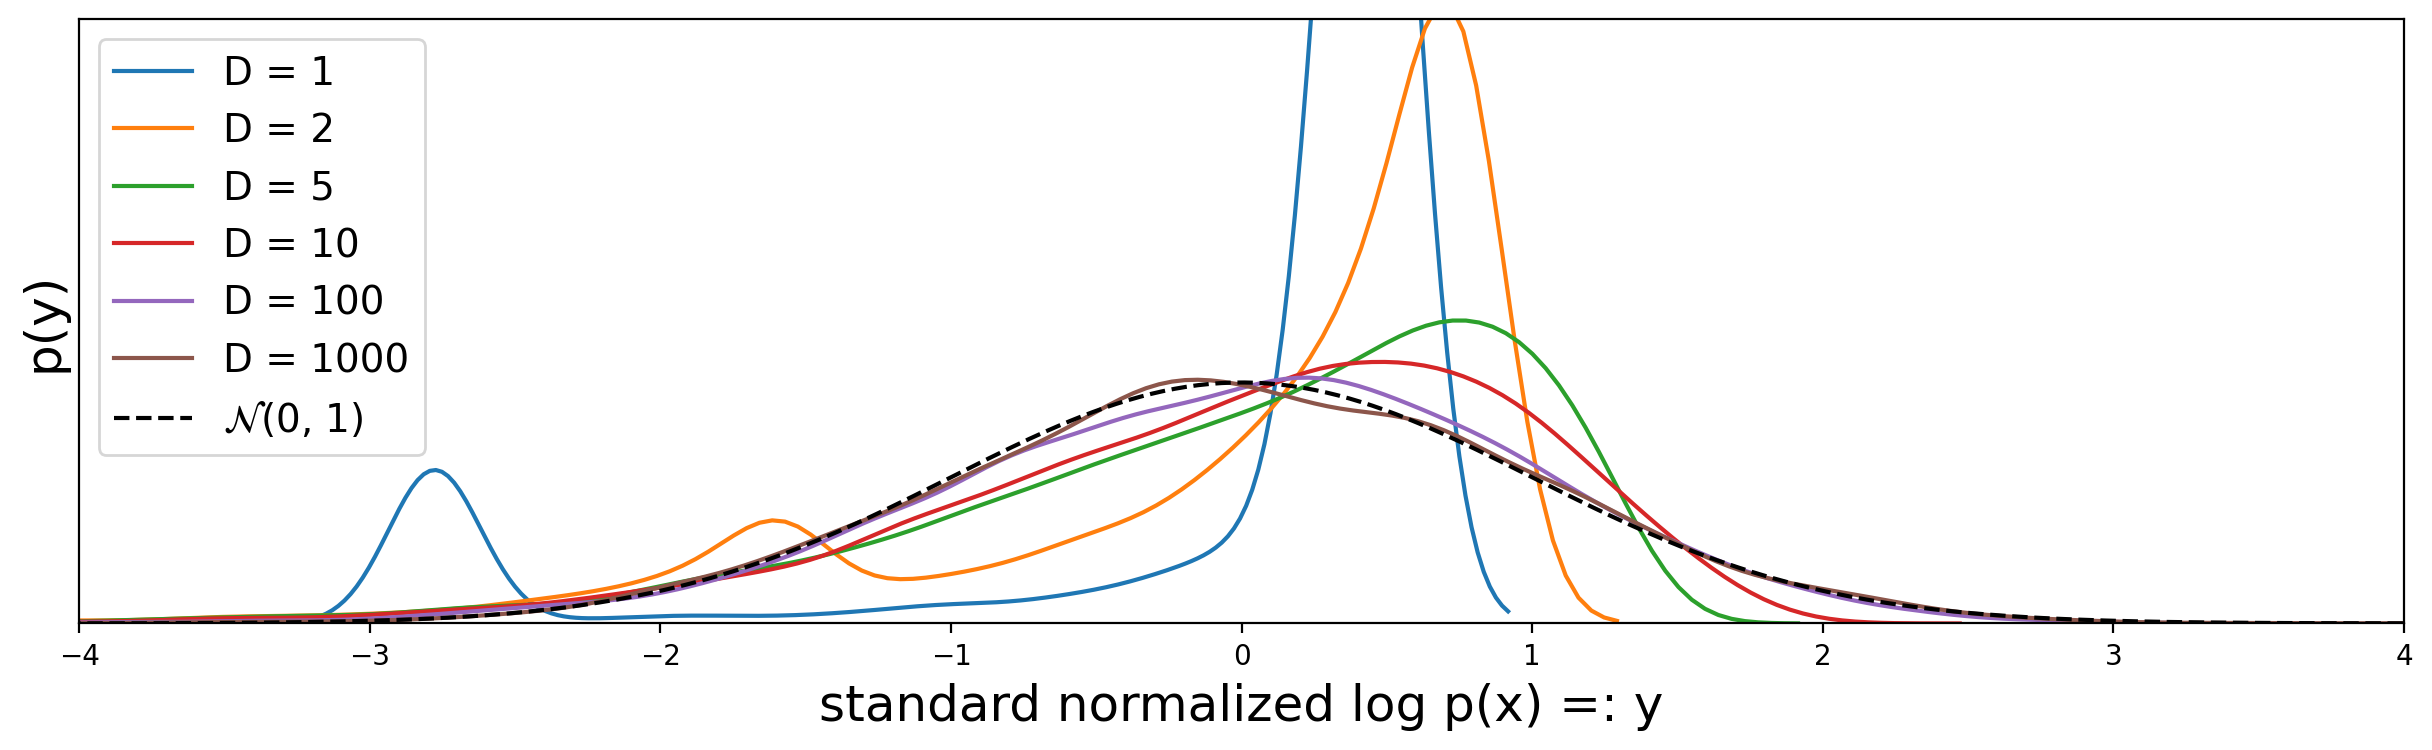

In [69]:
LEFT_QUANTILE_CUT_OFF = 0.01
STATE_DENSITY_SAMPLE_COUNT = 10000

fig_axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 4), squeeze=False, dpi=200)
#axs = plot_state_density_variance_transition('smooth_step', 'dimension', used_dimensions=[1, 2, 4, 8, 64, 128], used_variances=[1e-6], normalization='central_limit')
axs = plot_state_density_variance_transition('smooth_step', 'dimension', used_dimensions=[1, 2, 5, 10, 100, 1000],#, 10000], 
                                             used_variances=[1e-2], normalization='central_limit',
                                             fig_axs=fig_axs, plot_legend=False)
#axs[0].set_xlim(right=3)
#axs[0].set_xlim([-10, 10])
axs[0].set_xlim([-4, 4])
axs[0].set_ylim(top=1)
axs[0].set_ylabel('p(y)', size=AXIS_TITLE_SIZE)
plt.title('')

axs[0].legend(loc='upper left', fontsize=LEGEND_SIZE)
#axs[0].set_size_inches(5, 2.5)

plt.savefig('E:/central_limit.pdf', format='pdf', bbox_inches='tight')

In [62]:
LEFT_QUANTILE_CUT_OFF = 0.01
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('normal', 'dimension', used_variances=[0])

In [14]:
LEFT_QUANTILE_CUT_OFF = 0.01
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('smooth_step', 'dimension')

In [12]:
#plot_state_density_variance_transition('mises', 'dimension')

In [11]:
LEFT_QUANTILE_CUT_OFF = 0
STATE_DENSITY_SAMPLE_COUNT = 1000
#plot_state_density_variance_transition('line', 'dimension')

In [10]:
LEFT_QUANTILE_CUT_OFF = 0.00
STATE_DENSITY_SAMPLE_COUNT = 20000

#plot_state_density_variance_transition('smooth_step', 'variance', used_dimensions=[2, 3], used_variances=[0, -5, -10, -20],
#                                      file_extension='show')

special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²= ${10^ {0} }$) Var: 0.0 Dim: 2 Mean: -3.232
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²= ${10^ {-2} }$) Var: -5.0 Dim: 2 Mean: 2.540
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²= ${10^ {-4} }$) Var: -10.0 Dim: 2 Mean: 8.280


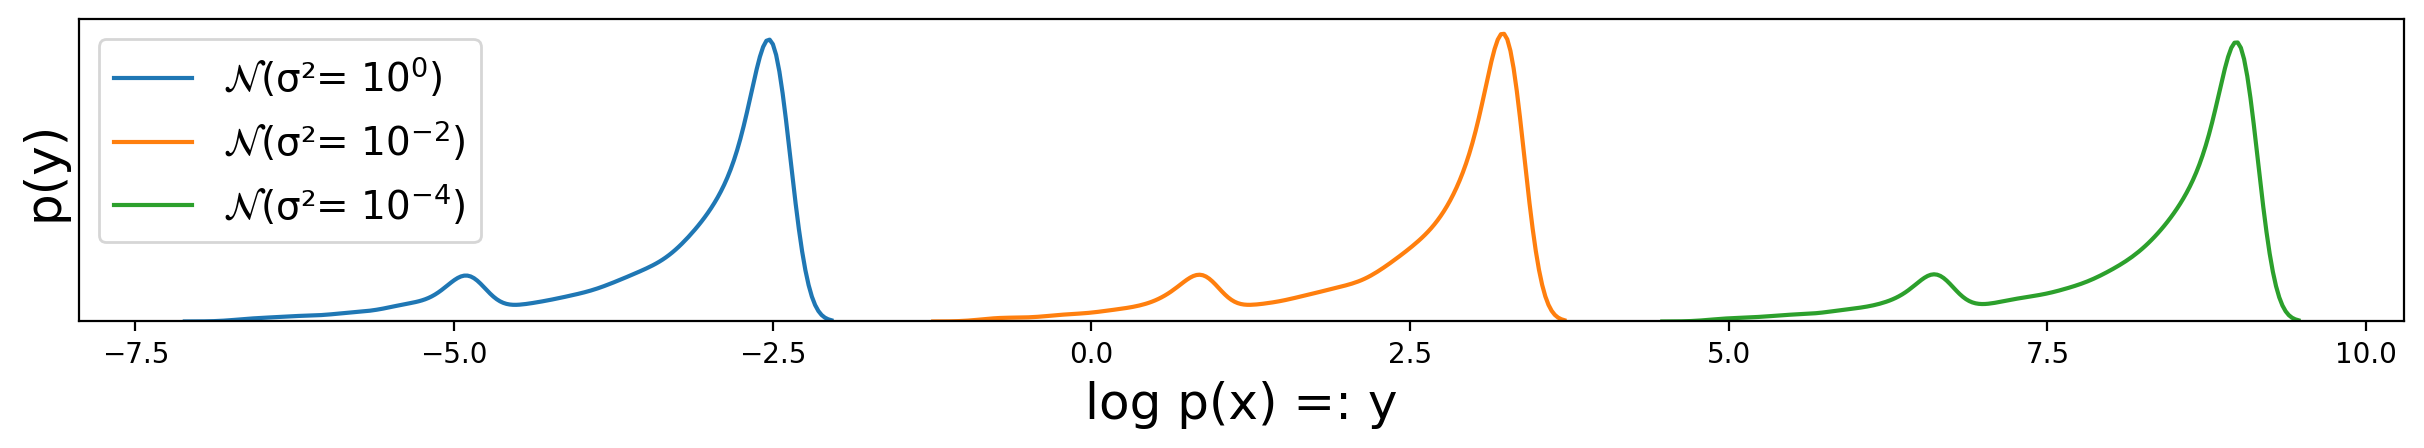

In [66]:
%matplotlib inline
STATE_DENSITY_SAMPLE_COUNT = 20000
axs = plot_state_density_variance_transition('smooth_step', 'variance', used_dimensions=[2], used_variances=[0, -5, -10], 
                                             file_extension='show', normalization=None, plot_legend=False)
#axs = plot_state_density_variance_transition('smooth_step', 'variance', used_dimensions=[2], used_variances=[0, -5,], file_extension='show', normalization=None)
axs[0].set_ylabel('p(y)', fontsize=AXIS_TITLE_SIZE)
axs[0].legend(fontsize=LEGEND_SIZE)
plt.title('')
plt.savefig('E:/mani_dos_translation.pdf', format='pdf', bbox_inches='tight')

In [99]:
LEFT_QUANTILE_CUT_OFF = 0.01
STATE_DENSITY_SAMPLE_COUNT = 10000

error
fig_axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 4), squeeze=False, dpi=200)
#axs = plot_state_density_variance_transition('smooth_step', 'dimension', used_dimensions=[1, 2, 4, 8, 64, 128], used_variances=[1e-6], normalization='central_limit')
#axs = plot_state_density_variance_transition('smooth_step', 'dimension', used_dimensions=[1, 2, 5, 10, 100, 1000],#, 10000], 
#                                             used_variances=[1e-2],
#                                             fig_axs=fig_axs, plot_legend=False)
#axs[0].set_xlim(right=3)
#axs[0].set_xlim([-10, 10])
axs[0].set_xlim([-4, 4])
axs[0].set_ylim(top=1)
axs[0].set_ylabel('p(y)')
plt.title('')

axs[0].legend(loc='upper right')
#axs[0].set_size_inches(5, 2.5)

plt.savefig('E:/central_limit.pdf', format='pdf', bbox_inches='tight')

NameError: name 'error' is not defined

In [9]:
#plot_state_density_variance_transition('smooth_step', 'variance', used_dimensions=[2, 36, 100, 196], used_variances=[-6, -4, -2, -1], file_extension='show')

[-2, -1, 0, 1, 2]
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²=${10^ {-2} }$) Var: -2.0 Dim: 5 Mean: 2.178
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²=${10^ {-1} }$) Var: -1.0 Dim: 5 Mean: -2.428
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²=${10^ {0} }$) Var: 0.0 Dim: 5 Mean: -7.034
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²=${10^ {1} }$) Var: 1.0 Dim: 5 Mean: -11.636
special case activated;  no noise to manifold
$\mathcal{{N}}$(σ²=${10^ {2} }$) Var: 2.0 Dim: 5 Mean: -16.241


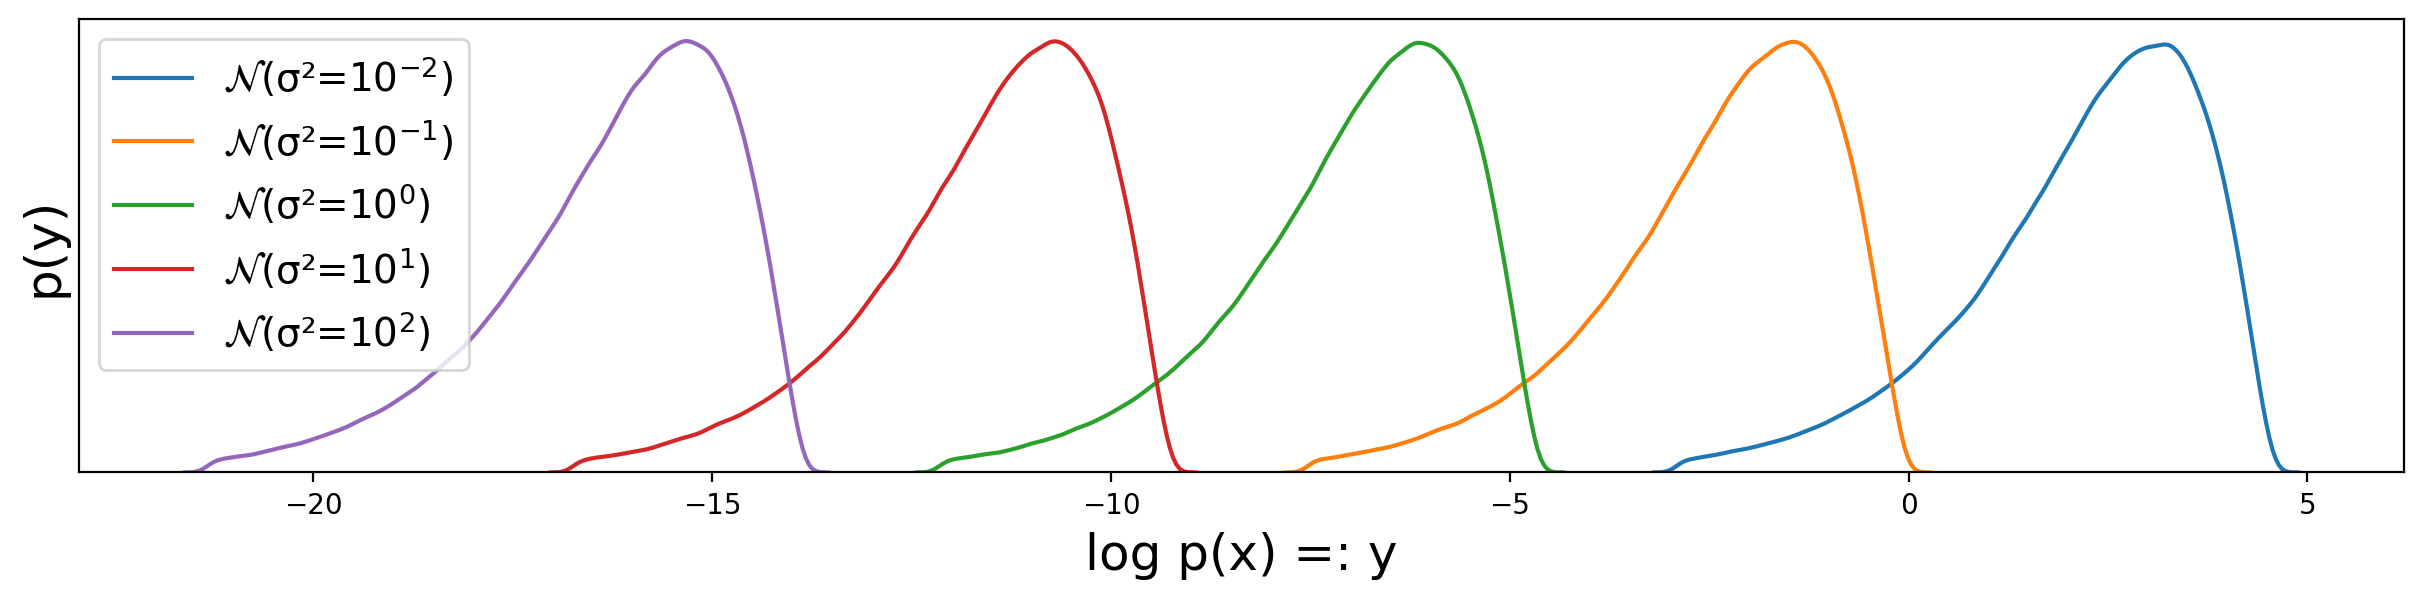

In [111]:
STATE_DENSITY_SAMPLE_COUNT = 1000000
fig_axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 3), squeeze=False, dpi=200)
axs = plot_state_density_variance_transition('normal', 'variance', used_dimensions=[5], used_variances=[-2, -1, 0, 1, 2], 
                                            plot_legend=False, normalization=None, fig_axs=fig_axs)

#axs[0].set_xlim([-4, 4])
#axs[0].set_ylim(top=1)
axs[0].set_ylabel('p(y)', fontsize=AXIS_TITLE_SIZE)
axs[0].legend(fontsize=LEGEND_SIZE)
plt.title('')
#axs[0].set_size_inches(5, 2.5)

plt.savefig('E:/multi_normal_dos_shift.pdf', format='pdf', bbox_inches='tight')

N(σ²= 1e-6) Var: -6.0 Dim: 2 Mean: 2.073
N(σ²= 1e-4) Var: -4.0 Dim: 2 Mean: 0.896
N(σ²= 1e-2) Var: -2.0 Dim: 2 Mean: -0.239
N(σ²= 1e-1) Var: -1.0 Dim: 2 Mean: -0.813
N(σ²= 1e-6) Var: -6.0 Dim: 36 Mean: 5.302
N(σ²= 1e-4) Var: -4.0 Dim: 36 Mean: 3.068
N(σ²= 1e-2) Var: -2.0 Dim: 36 Mean: 0.823
N(σ²= 1e-1) Var: -1.0 Dim: 36 Mean: -0.297
N(σ²= 1e-6) Var: -6.0 Dim: 100 Mean: 5.422
N(σ²= 1e-4) Var: -4.0 Dim: 100 Mean: 3.142
N(σ²= 1e-2) Var: -2.0 Dim: 100 Mean: 0.864
N(σ²= 1e-1) Var: -1.0 Dim: 100 Mean: -0.276
N(σ²= 1e-6) Var: -6.0 Dim: 196 Mean: 5.455
N(σ²= 1e-4) Var: -4.0 Dim: 196 Mean: 3.163
N(σ²= 1e-2) Var: -2.0 Dim: 196 Mean: 0.869
N(σ²= 1e-1) Var: -1.0 Dim: 196 Mean: -0.275


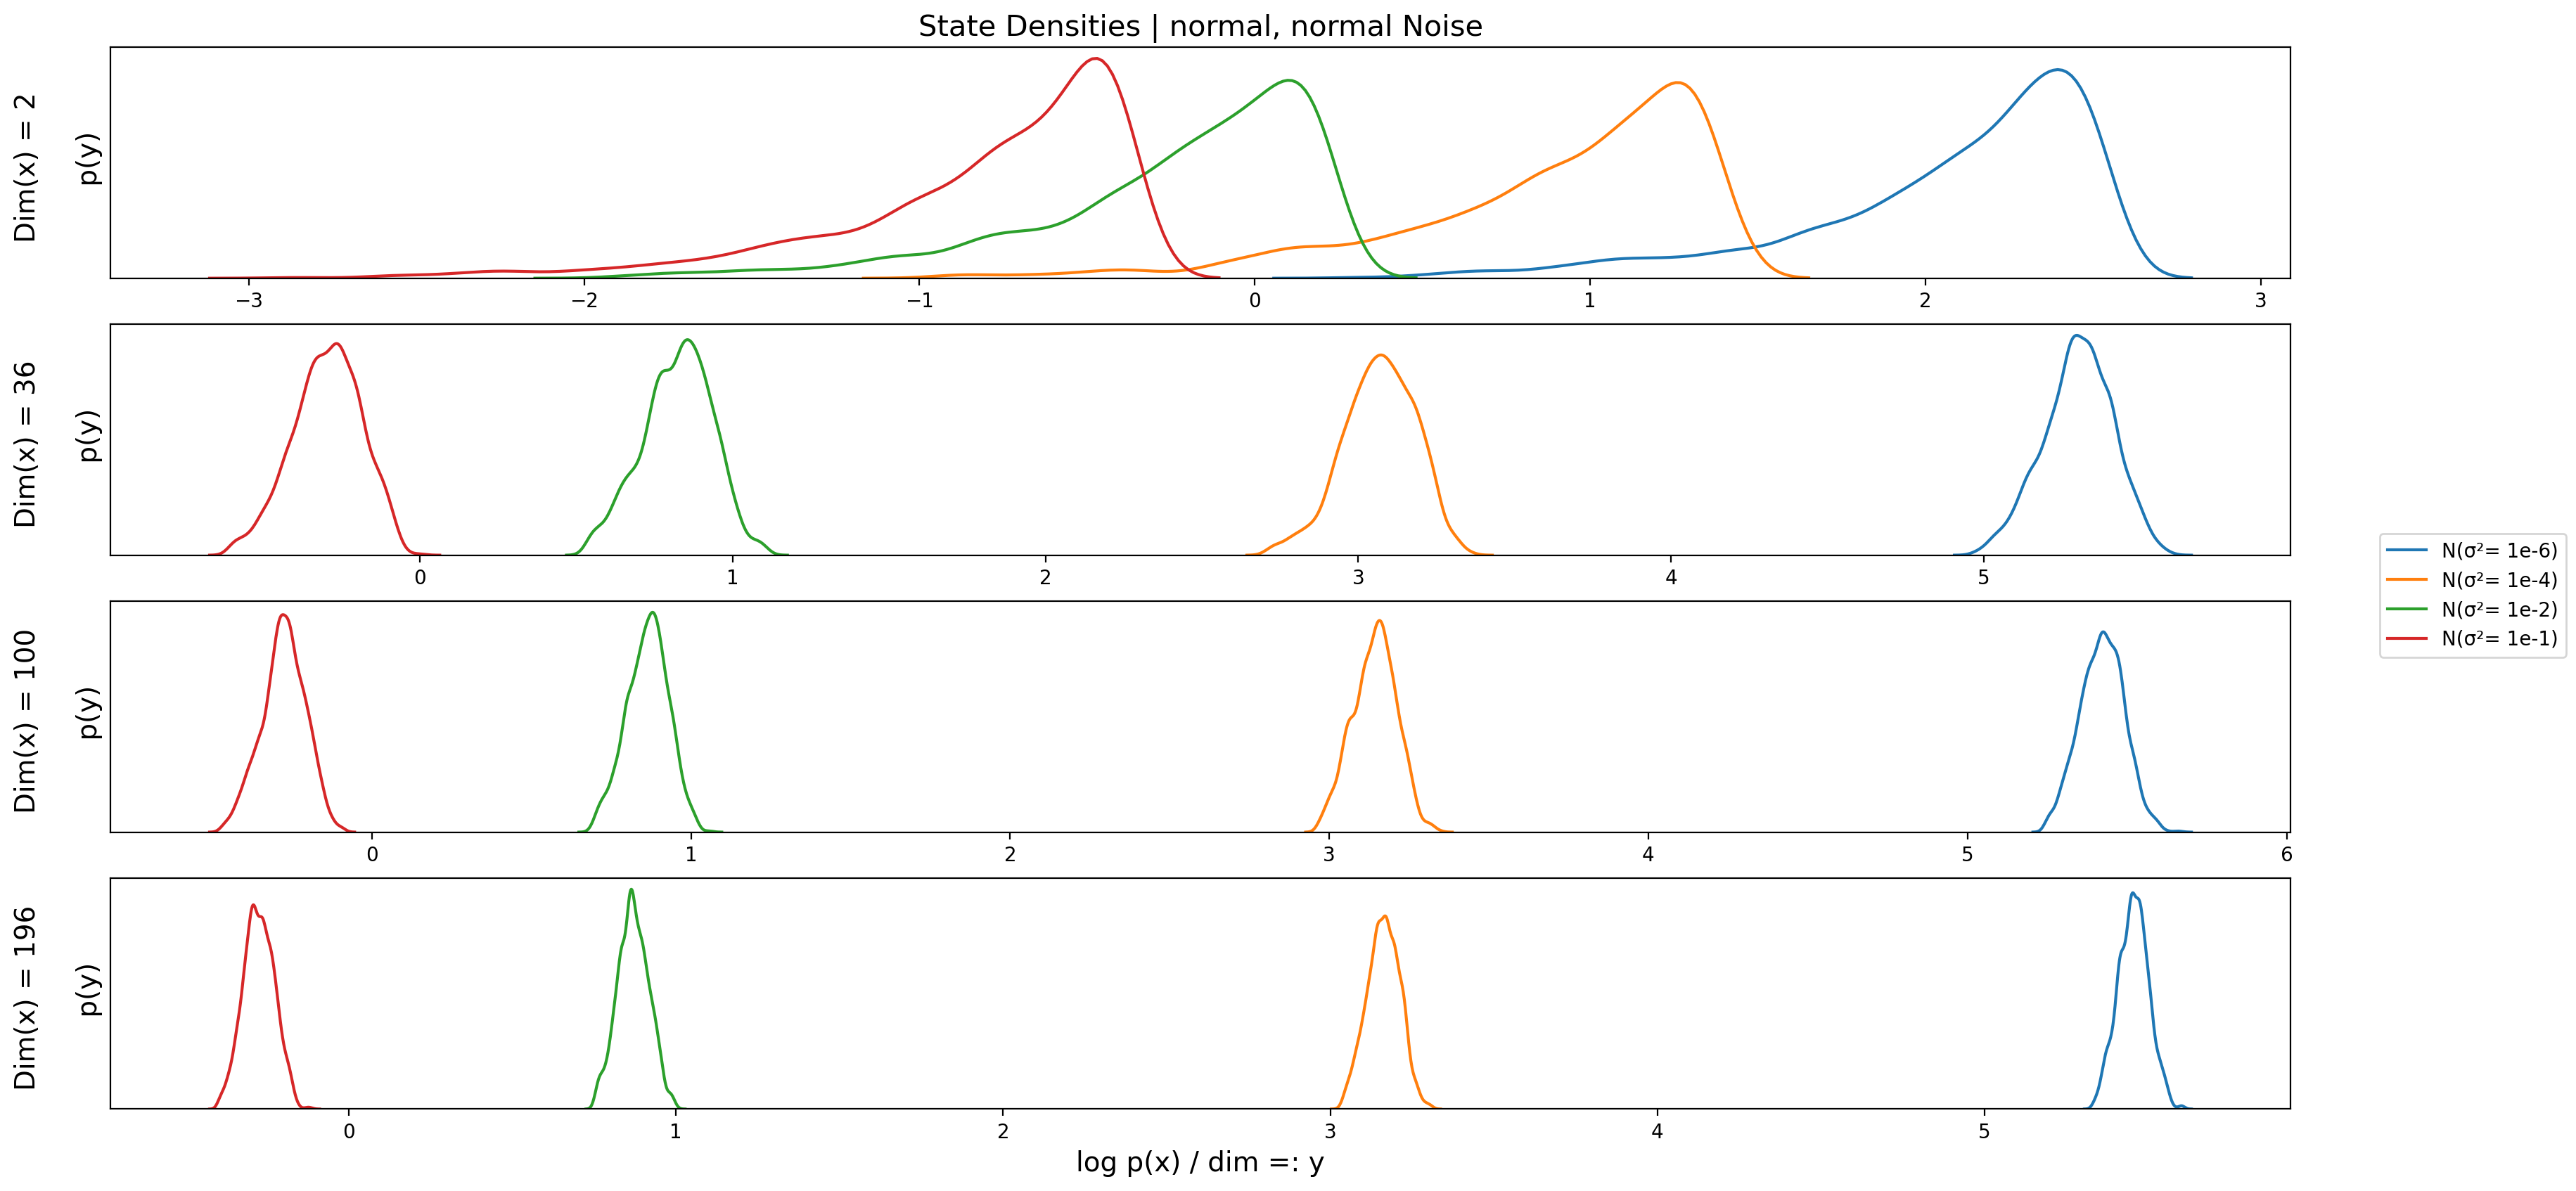

In [16]:
plot_state_density_variance_transition('normal', 'variance', used_dimensions=[2, 36, 100, 196], used_variances=[-6, -4, -2, -1], file_extension='show')

In [12]:
#plot_state_density_variance_transition('line', 'variance', used_dimensions=[2, 3], used_variances=[0, -5, -10, -20],
#                                      file_extension='show')

In [8]:
#plot_state_density_variance_transition('mises', 'variance', used_dimensions=[2, 3], used_variances=[0, -5, -10, -20], 
#                                       file_extension='show')

----------

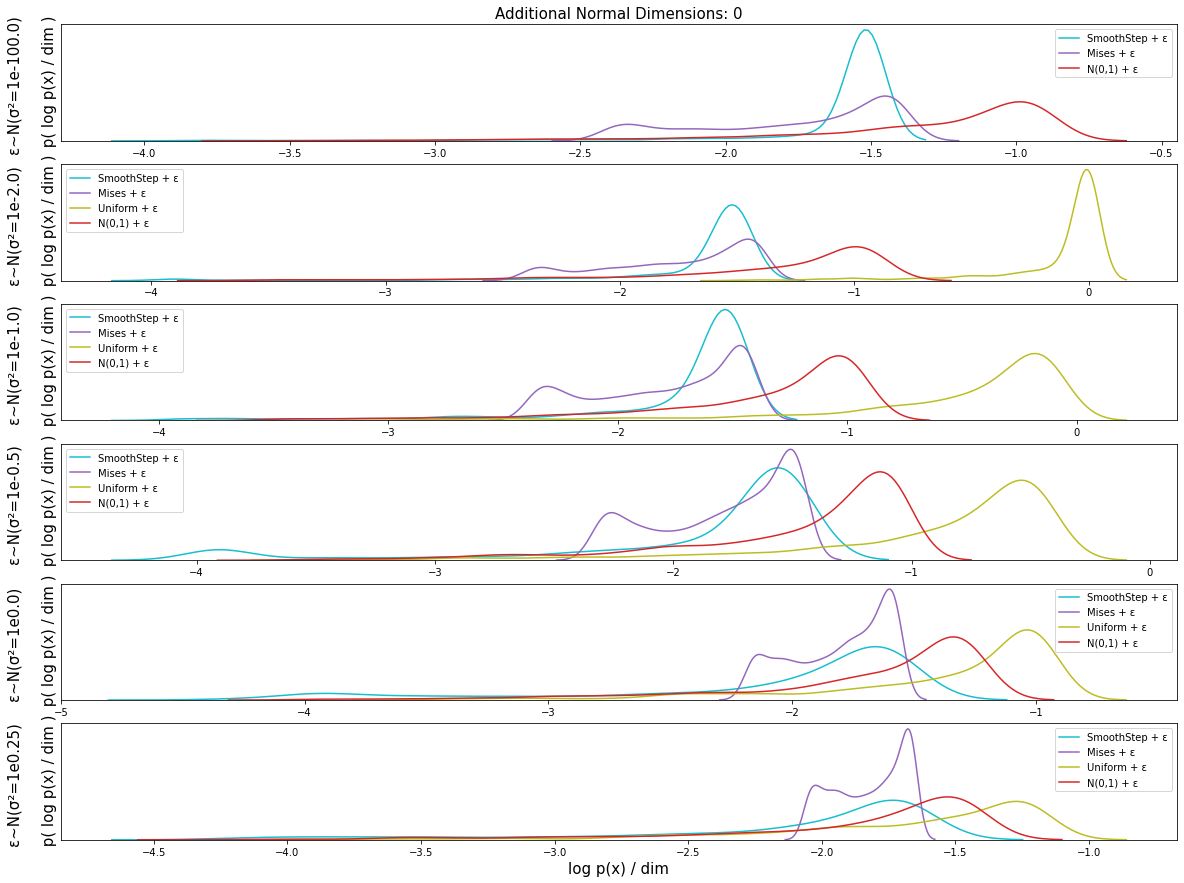

In [167]:
    
def plot_density_states_with_normal_noise(variance, log, ax, additional_dimensions):
    """inflated_dimensions: first dim is i.e. Mises + Noise. All other dimensions contain normal noise with the same variance """
    kwargs = dict(variance=variance, ax=ax, log=log, additional_dimensions=additional_dimensions)
    #ax.set_yscale('log')
    step_data = SmoothstepData(**smoothstep_params, train_size=10)
    density_state_add_normal_noise(sampling=step_data._sample_on_manifold, pdf=step_data.pdf_on_manifold, 
                                   label='SmoothStep + ε', color=step_clr, **kwargs)
    
    density_state_add_normal_noise(sampling=vonmises.rvs, pdf=vonmises.pdf, **mises_params_05, 
                                   label='Mises + ε', color=mises_clr, **kwargs)
    density_state_add_normal_noise(sampling=uniform.rvs, pdf=uniform.pdf, **uniform_params,
                                   label='Uniform + ε', color=uni_clr, **kwargs)
    density_state_add_normal_noise(sampling=norm.rvs, pdf=norm.pdf, **norm_params,
                                   label='N(0,1) + ε', color=gauss_clr, **kwargs)
    
    #density_state_add_normal_noise(vonmises.rvs, vonmises.pdf, 1e-2, **mises_params_4, label='Mises k=4', color='b')
    norm_pds = np.ones((STATE_DENSITY_SAMPLE_COUNT,))
    if log:
        norm_pds *= 0
    
    # +1 because one dimension is the "normal one" (instead of e.g. Mises)
    norm_pds = add_density_of_normal_dimensions(norm_pds, additional_dimensions+1, scale=np.sqrt(variance), log=log)
    #dist_plotter(norm_pds, 'ε', color=noise_clr, ax=ax)
    
    log_txt = 'log ' if log else ''
    ax.set_ylabel(f'ε~N(σ²=1e{np.log10(variance)}) \n\n p( {log_txt}p(x) / dim )')
    ax.set_yticks([])
    
def density_with_noise_plotter(additional_dimensions, log):
    NOISE_LEVELS = [-100, -2, -1, -0.5, 0, 0.25]
    fig, axs = plt.subplots(nrows=len(NOISE_LEVELS), ncols=1, figsize=(20, int(len(NOISE_LEVELS)*2.5)), squeeze=True)

    for i, noise in enumerate(NOISE_LEVELS):
        plot_density_states_with_normal_noise(variance=10**noise, log=log, ax=axs[i], additional_dimensions=additional_dimensions)

    log_txt = 'log ' if log else ''
    axs[-1].set_xlabel(f'{log_txt}p(x) / dim')
    axs[0].set_title(f'Density of States | Additional Normal Dimensions: {additional_dimensions}', size=TITLE_SIZE)
    axs_formatter(axs, TITLE_SIZE)
    
    fig.savefig(f'densities/{log_txt}state_dense_plus_noise_dim{additional_dimensions}.png')
    
    return axs

def set_all_xlims(axs, left_xlim):
    for ax in axs:
        if ax.get_xlim()[0] < left_xlim:
            ax.set_xlim(left=left_xlim)

STATE_DENSITY_SAMPLE_COUNT = 10000
STATE_DENSITY_SAMPLE_COUNT = 1000
axs = density_with_noise_plotter(0, log=True)
set_all_xlims(axs, -5)

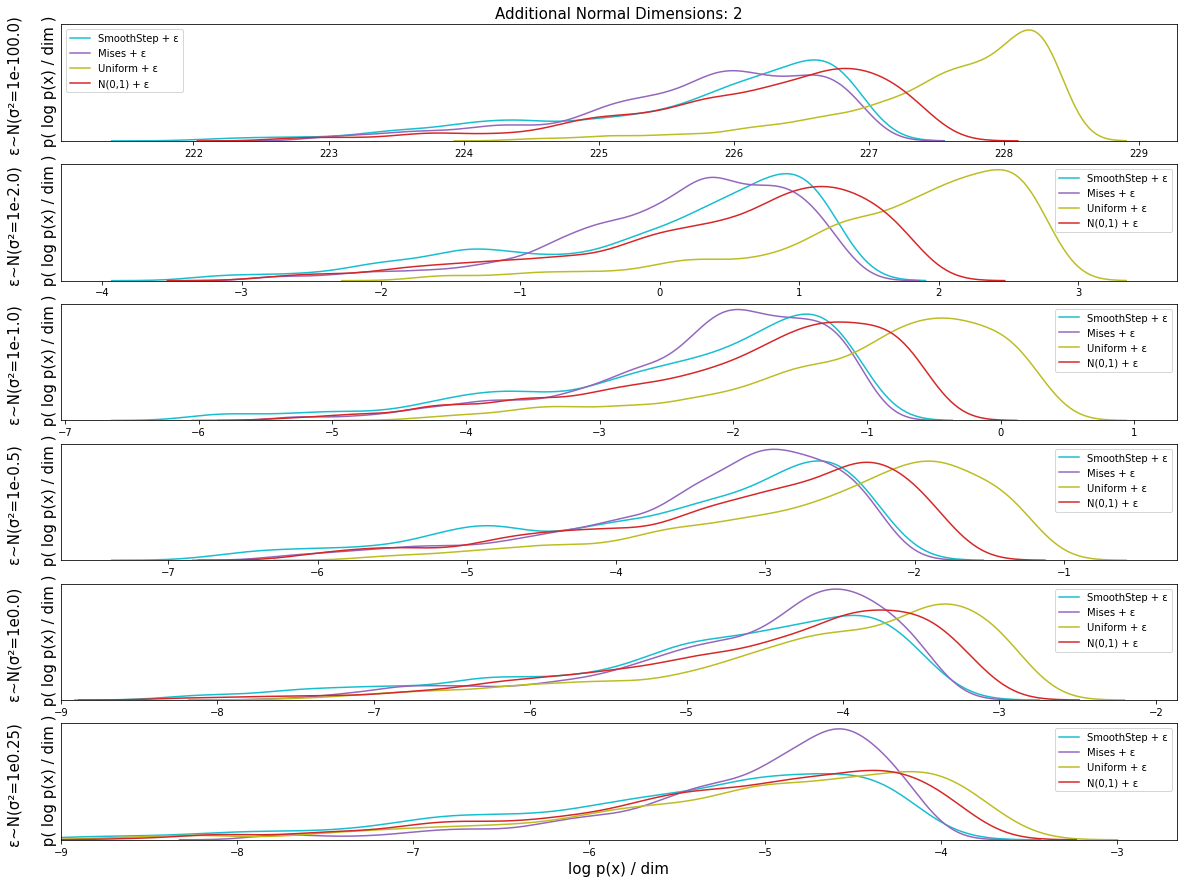

In [162]:
axs = density_with_noise_plotter(2, log=True)
set_all_xlims(axs, -9)

In [17]:
#density_with_noise_plotter(4, log=True)

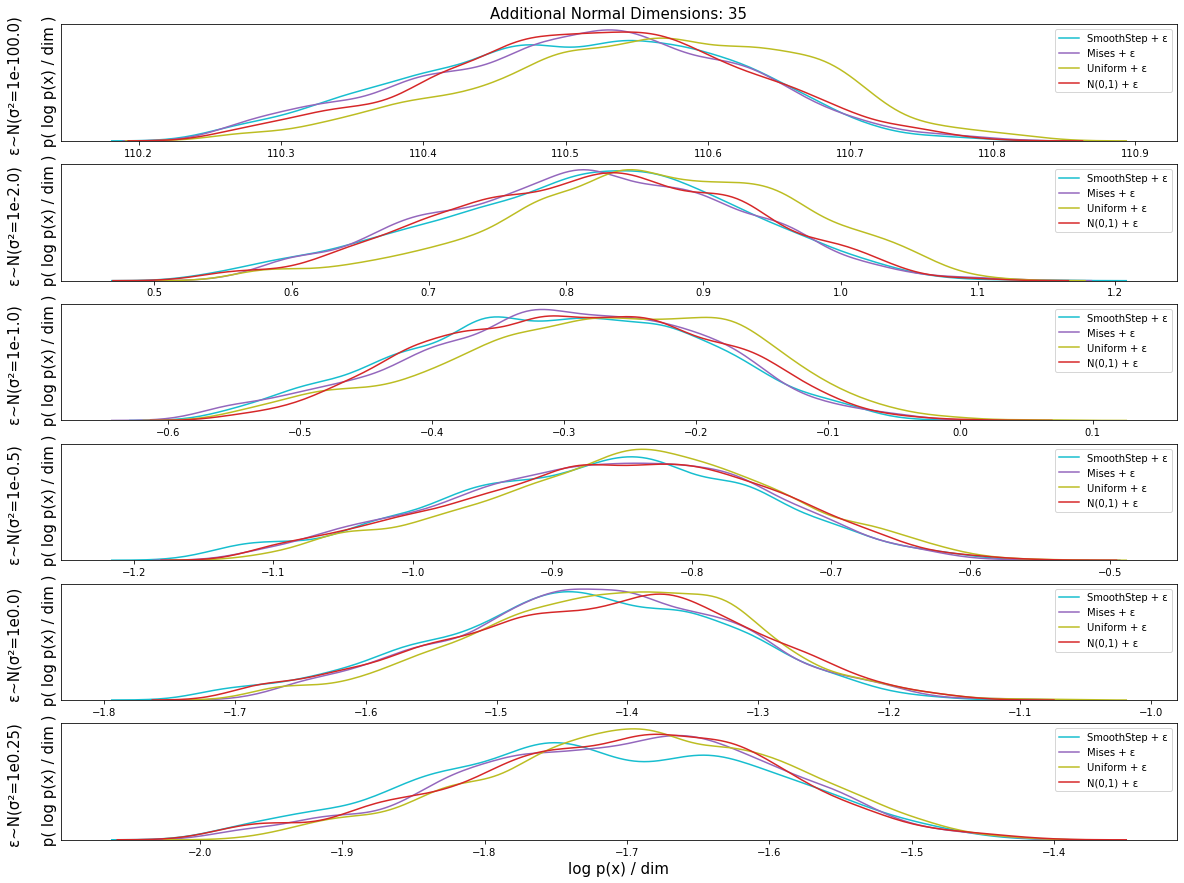

In [165]:
_=density_with_noise_plotter(35, log=True)

array([<AxesSubplot:title={'center':'Additional Normal Dimensions: 195'}, ylabel='ε~N(σ²=1e-100.0) \n\n p( log p(x) / dim )'>,
       <AxesSubplot:ylabel='ε~N(σ²=1e-2.0) \n\n p( log p(x) / dim )'>,
       <AxesSubplot:ylabel='ε~N(σ²=1e-1.0) \n\n p( log p(x) / dim )'>,
       <AxesSubplot:ylabel='ε~N(σ²=1e-0.5) \n\n p( log p(x) / dim )'>,
       <AxesSubplot:ylabel='ε~N(σ²=1e0.0) \n\n p( log p(x) / dim )'>,
       <AxesSubplot:xlabel='log p(x) / dim', ylabel='ε~N(σ²=1e0.25) \n\n p( log p(x) / dim )'>],
      dtype=object)

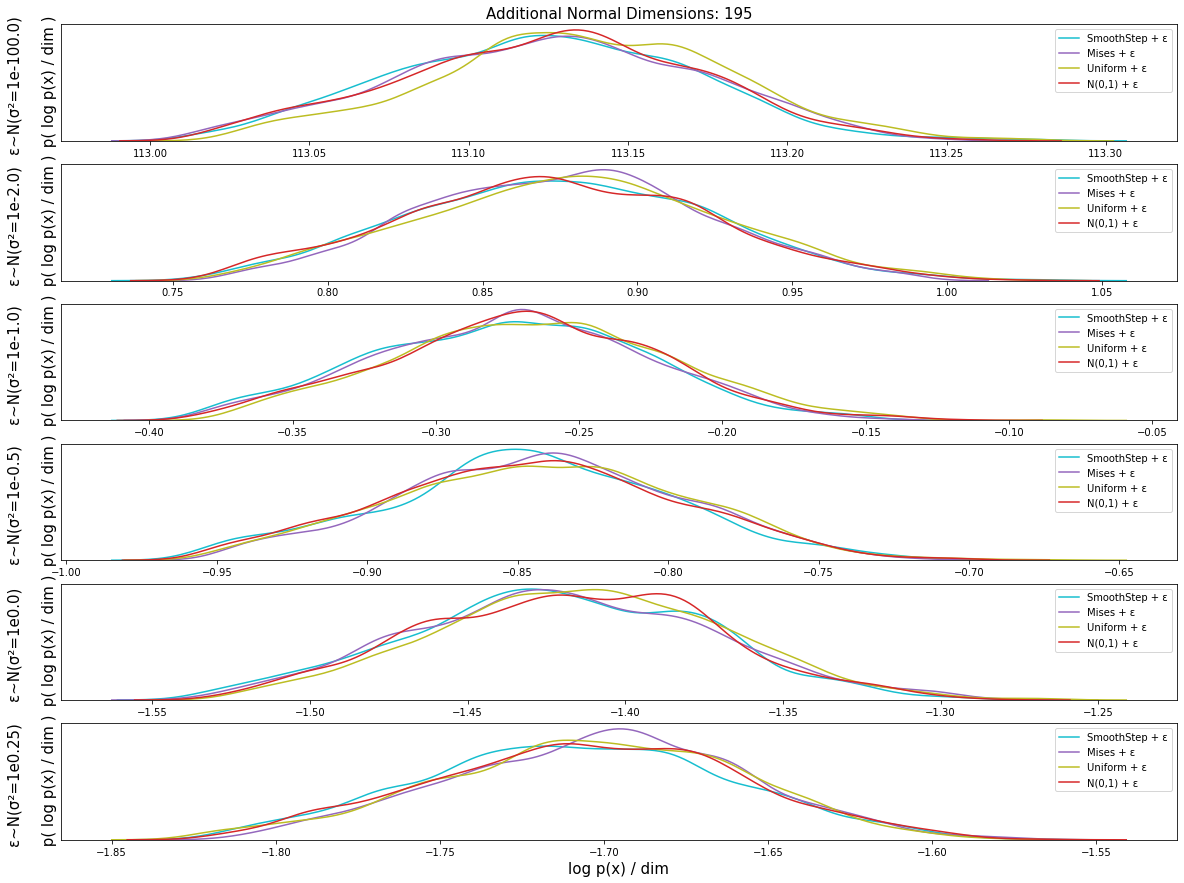

In [166]:
_=density_with_noise_plotter(195, log=True)

-------------

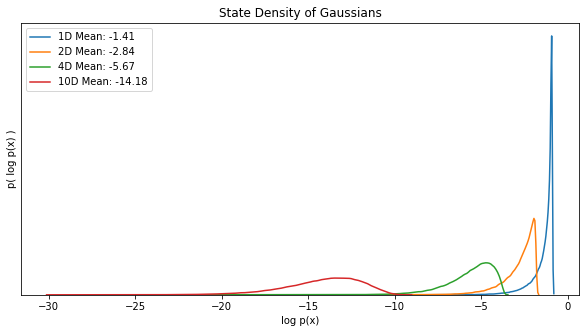

In [7]:
def dens_state_multi_norm(cov, ax=None, label=None, log=True, size=None):
    if size is None:
        size = 100000
    x = multivariate_normal.rvs(size=size, cov=cov)
    if log:
        pds = multivariate_normal.logpdf(x, cov=cov)#, allow_singular=True)
    else:
        pds = multivariate_normal.pdf(x, cov=cov)
    if label is None:
        label = f'gauss_symbol()(0, {cov})'
    label += f' Mean: {pds.mean():.2f}'
    
    sns.distplot(pds, ax=ax, label=label, hist=False, kde_kws={'bw_adjust': 0.5}, kde=True, bins=100) # kde_kws={'cumulative':True})
    
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=True) # , dpi=100

#ens_state_multi_norm([[1,2], [2,5]])
dens_state_multi_norm(np.eye(1), label='1D')
dens_state_multi_norm(np.eye(2), label='2D')
dens_state_multi_norm(np.eye(4), label='4D')
dens_state_multi_norm(np.eye(10), label='10D')

def gauss_state_dens_plot_labeling():
    plt.xlabel('log p(x)')
    plt.ylabel('p( log p(x) )')
    plt.title('Density of States of Gaussians')
    #dens_state_multi_norm(np.eye(4)*10**-1)
    plt.legend()
    plt.yticks([])
    
gauss_state_dens_plot_labeling()

fig.savefig(f'random/gauss state densities.png', bbox_inches='tight')

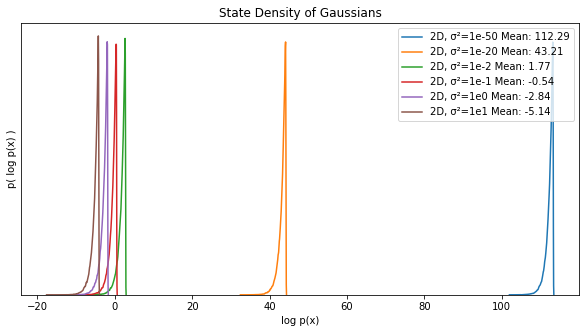

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=True)
for var in [-50, -20, -2, -1, 0, 1]:
    dens_state_multi_norm(10**var * np.eye(2), label=f'2D, σ²=1e{var}')
gauss_state_dens_plot_labeling()

fig.savefig(f'random/gauss state dense var.png')

---------